In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer
from PIL import Image

class CLIPCrossAttention(nn.Module):
    def __init__(self, clip_model_name="openai/clip-vit-base-patch32"):
        super().__init__()
        # Load mô hình CLIP đã được huấn luyện
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        self.tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
        
        # Đóng băng các tham số của CLIP (tùy chọn)
        for param in self.clip.parameters():
            param.requires_grad = False
            
        # Lấy kích thước hidden dimension từ CLIP
        self.vision_hidden_dim = self.clip.vision_embed_dim
        self.text_hidden_dim = self.clip.text_embed_dim
        
        # Projection layers để đưa về cùng dimension nếu cần
        self.text_proj = nn.Linear(self.text_hidden_dim, self.vision_hidden_dim)
        
        # Layer normalization
        self.norm = nn.LayerNorm(self.vision_hidden_dim)
        
        # Cross-attention layer
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.vision_hidden_dim,
            num_heads=8,
            batch_first=True
        )
        
    def forward(self, image, text_tokens):
        """
        Args:
            image: Tensor ảnh [batch, 3, H, W]
            text_tokens: Dictionary chứa input_ids và attention_mask
                        từ tokenizer: {'input_ids': tensor, 'attention_mask': tensor}
        
        Returns:
            attention_map: Feature map tập trung vào vùng quan trọng [batch, 1, H', W']
        """
        # Lấy patch embeddings từ vision encoder
        vision_outputs = self.clip.vision_model(
            pixel_values=image,
            output_hidden_states=True
        )
        patch_embeddings = vision_outputs.last_hidden_state  # [batch, num_patches+1, hidden_dim]
        
        # Loại bỏ class token, chỉ lấy patch embeddings
        patch_embeddings = patch_embeddings[:, 1:, :]  # [batch, num_patches, hidden_dim]
        
        # Lấy text embeddings từ text encoder
        text_outputs = self.clip.text_model(
            input_ids=text_tokens['input_ids'],
            attention_mask=text_tokens['attention_mask']
        )
        text_embeddings = text_outputs.last_hidden_state  # [batch, seq_len, hidden_dim]
        
        # Project text embeddings sang cùng dimension với vision
        text_embeddings = self.text_proj(text_embeddings)
        text_embeddings = self.norm(text_embeddings)
        
        # Thực hiện cross-attention
        # Query: text embeddings, Key/Value: patch embeddings
        attention_output, attention_weights = self.cross_attention(
            query=text_embeddings,
            key=patch_embeddings,
            value=patch_embeddings,
            need_weights=True
        )
        
        # Lấy attention weights từ token [EOS] (thường là token cuối cùng)
        # Hoặc có thể lấy trung bình trên tất cả text tokens
        eos_attention = attention_weights[:, -1, :]  # [batch, num_patches]
        
        # Reshape thành attention map dạng 2D
        batch_size = image.shape[0]
        num_patches = patch_embeddings.shape[1]
        
        # Giả sử ảnh được chia thành grid (patch_size=32, image_size=224 -> grid 7x7)
        grid_size = int(num_patches ** 0.5)
        attention_map = eos_attention.view(batch_size, 1, grid_size, grid_size)
        
        # Interpolate về kích thước ảnh gốc
        attention_map = F.interpolate(
            attention_map,
            size=(image.shape[2], image.shape[3]),
            mode='bilinear',
            align_corners=False
        )
        
        return attention_map, eos_attention

# Hàm tiện ích để xử lý ảnh và văn bản
class CLIPAttentionPipeline:
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        self.model = CLIPCrossAttention(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        
    def process(self, image_path, text):
        """
        Xử lý ảnh và văn bản để tạo attention map
        
        Args:
            image_path: Đường dẫn đến ảnh
            text: Văn bản mô tả
        
        Returns:
            attention_map: Feature map nhấn mạnh vùng liên quan đến text
            processed_image: Ảnh đã được xử lý
        """
        # Load và preprocess ảnh
        image = Image.open(image_path).convert("RGB")
        
        # Xử lý ảnh
        processed_image = self.processor(
            images=image,
            return_tensors="pt"
        )["pixel_values"]
        
        # Xử lý văn bản
        text_tokens = self.processor(
            text=text,
            return_tensors="pt",
            padding=True
        )
        
        # Chuyển model sang eval mode
        self.model.eval()
        
        # Tạo attention map
        with torch.no_grad():
            attention_map, _ = self.model(processed_image, text_tokens)
        
        return attention_map.squeeze().cpu().numpy(), processed_image

# Hàm visualize kết quả
def visualize_attention(image_path, text, model_name="openai/clip-vit-base-patch32"):
    """
    Hàm tiện ích để visualize attention map
    
    Args:
        image_path: Đường dẫn đến ảnh
        text: Văn bản mô tả
        model_name: Tên mô hình CLIP
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Khởi tạo pipeline
    pipeline = CLIPAttentionPipeline(model_name)
    
    # Xử lý ảnh và văn bản
    attention_map, processed_image = pipeline.process(image_path, text)
    
    print(f"Attention map shape: {attention_map.shape}")
    print(f"Processed image shape: {processed_image.shape}")
    
    # Chuẩn bị ảnh để hiển thị
    img_array = processed_image.squeeze().permute(1, 2, 0).cpu().numpy()
    
    # Denormalize ảnh (CLIP processor normalizes ảnh)
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    img_array = img_array * std + mean
    img_array = np.clip(img_array, 0, 1)
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 5))
    
    # Ảnh gốc
    plt.subplot(1, 3, 1)
    plt.imshow(img_array)
    plt.title(f"Original Image")
    plt.axis('off')
    
    # Attention map
    plt.subplot(1, 3, 2)
    plt.imshow(attention_map, cmap='hot')
    plt.title(f"Attention Map for '{text}'")
    plt.axis('off')
    plt.colorbar()
    
    # Overlay attention map lên ảnh
    plt.subplot(1, 3, 3)
    plt.imshow(img_array)
    
    # Tạo mask từ attention map
    attention_resized = np.clip(attention_map, 0, 1)
    attention_resized = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Overlay heatmap
    plt.imshow(attention_resized, cmap='jet', alpha=0.5)
    plt.title(f"Overlay: '{text}'")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return attention_map, img_array

# Ví dụ sử dụng
if __name__ == "__main__":
    # Test với ảnh và text
    image_path = "/home/hachi/PowerPaint/validation/test/2_b1/ground_truth.png"
    text = "sea shells"
    
    attention_map, img_array = visualize_attention(image_path, text)
    
    # Lưu attention map nếu cần
    # np.save("attention_map.npy", attention_map)
    # print("Attention map đã được lưu!")

/root/anaconda3/envs/powerpaint/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/anaconda3/envs/powerpaint/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


AssertionError: was expecting embedding dimension of 768, but got 512

Attention map shape: (224, 224)
Processed image shape: torch.Size([1, 3, 224, 224])


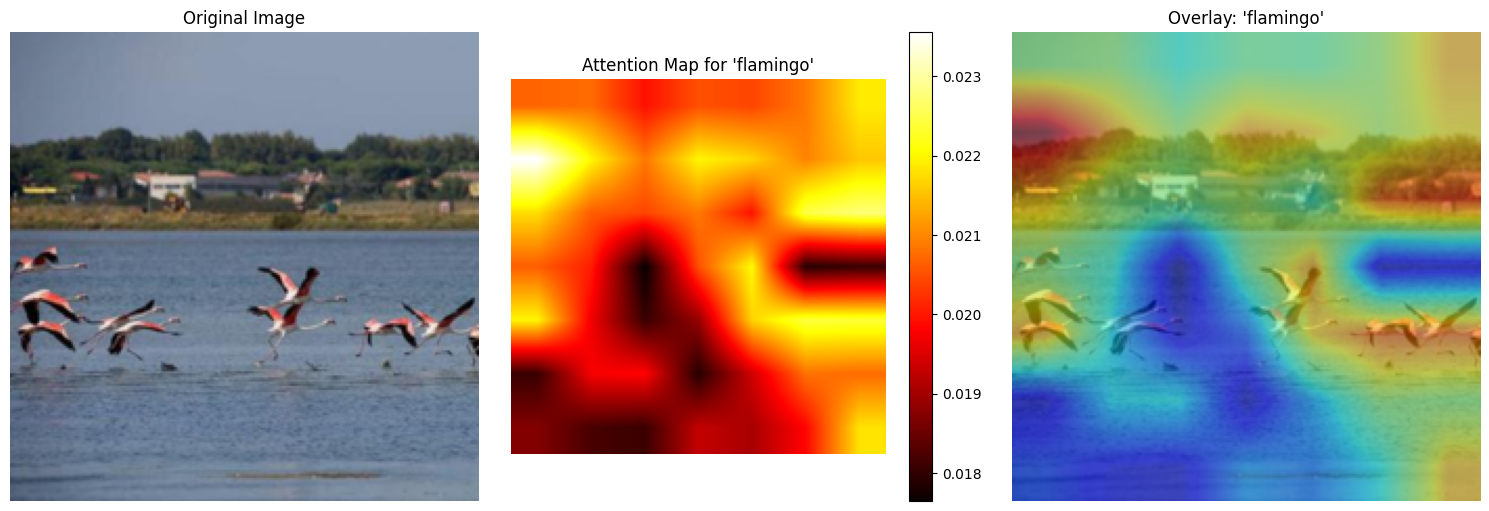

In [15]:
image_path = "/home/hachi/PowerPaint/validation/val/560_b1/ground_truth.png"
text = "flamingo"

attention_map, img_array = visualize_attention(image_path, text)

## Cosine similarity
just infer, no need to fine tune or training

In [ ]:
# kết hợp với examplar?

Analyzing image: /home/hachi/PowerPaint/validation/test/2_b1/ground_truth.png
Text query: 'sea shells'


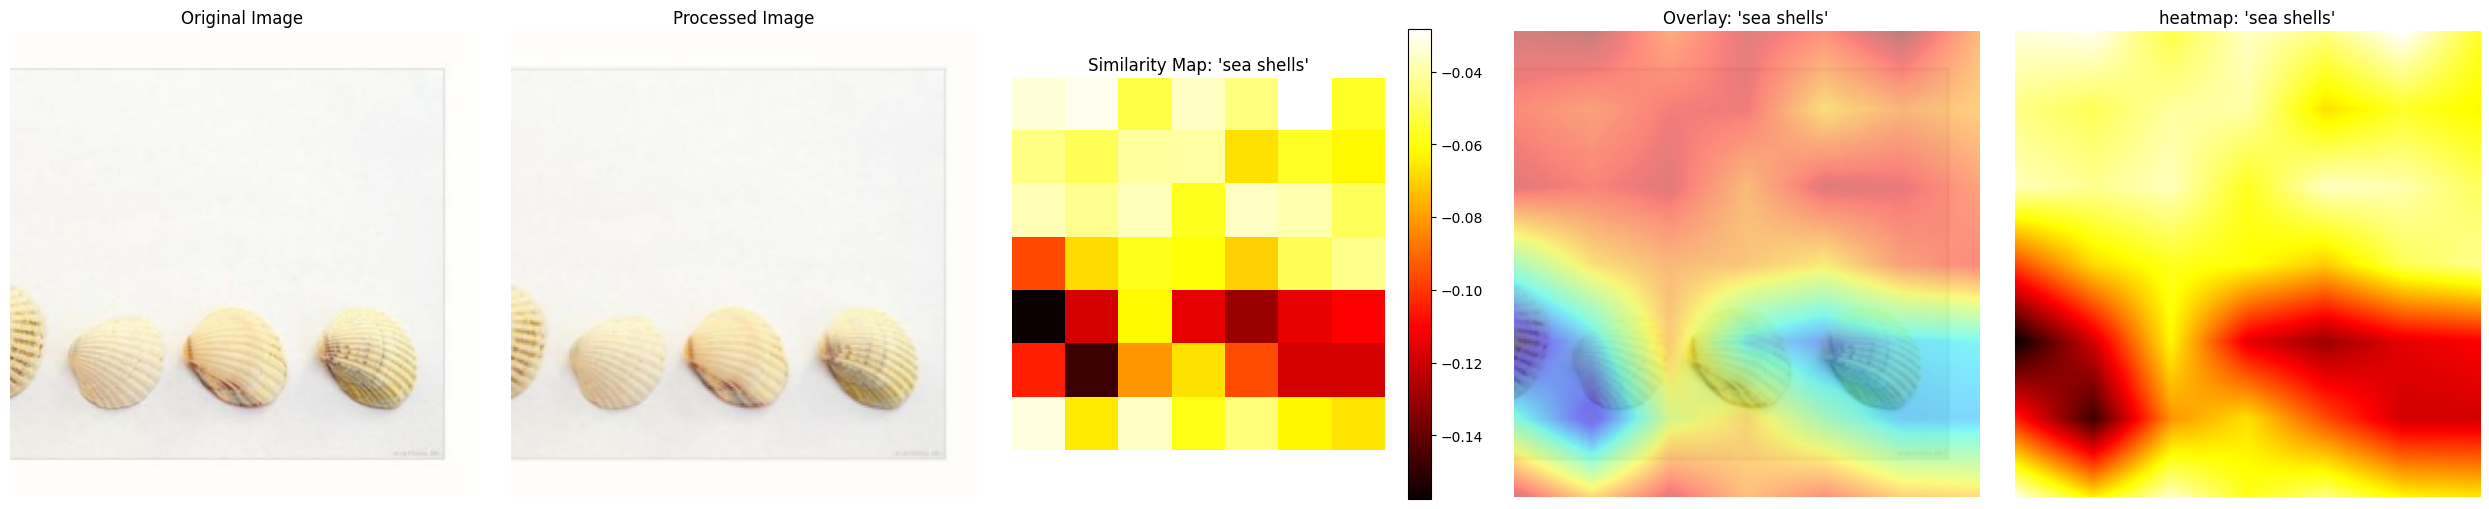


Top patches matching the text:
Grid size: 7x7
Patch 1: Index=5, Score=-0.0283, Grid Coordinate=(0, 5)
Patch 2: Index=1, Score=-0.0306, Grid Coordinate=(0, 1)
Patch 3: Index=42, Score=-0.0328, Grid Coordinate=(6, 0)
Patch 4: Index=0, Score=-0.0336, Grid Coordinate=(0, 0)
Patch 5: Index=3, Score=-0.0362, Grid Coordinate=(0, 3)
Patch 6: Index=18, Score=-0.0362, Grid Coordinate=(2, 4)
Patch 7: Index=44, Score=-0.0362, Grid Coordinate=(6, 2)
Patch 8: Index=16, Score=-0.0371, Grid Coordinate=(2, 2)
Patch 9: Index=14, Score=-0.0375, Grid Coordinate=(2, 0)
Patch 10: Index=19, Score=-0.0389, Grid Coordinate=(2, 5)


Comparing with multiple text queries:
'sea shells': Avg=-0.0673, Max=-0.0283
'ocean': Avg=-0.0797, Max=-0.0439
'sand': Avg=-0.0732, Max=-0.0401
'sky': Avg=-0.0804, Max=-0.0362
'water': Avg=-0.0854, Max=-0.0533


In [9]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt

class CLIPSimilarityMap:
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        """
        Khởi tạo với mô hình CLIP đã pretrained
        """
        self.model = CLIPModel.from_pretrained(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        
        # Chuyển sang eval mode và không cần gradient
        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False
    
    def get_text_embedding(self, text):
        """
        Lấy text embedding từ CLIP text encoder
        
        Args:
            text: Chuỗi văn bản
            
        Returns:
            text_embeds: Tensor shape [1, embedding_dim]
        """
        inputs = self.processor(text=text, return_tensors="pt", padding=True)
        
        with torch.no_grad():
            text_outputs = self.model.get_text_features(**inputs)
            # Chuẩn hóa embedding
            text_embeds = F.normalize(text_outputs, dim=-1)
        
        return text_embeds
    
    def get_patch_embeddings(self, image_path):
        """
        Lấy patch embeddings từ CLIP vision encoder
        
        Args:
            image_path: Đường dẫn đến ảnh
            
        Returns:
            patch_embeds: Tensor shape [num_patches, embedding_dim]
            image_tensor: Tensor ảnh đã xử lý
            original_size: Kích thước ảnh gốc
        """
        # Load và xử lý ảnh
        image = Image.open(image_path).convert("RGB")
        original_size = image.size  # (width, height)
        
        inputs = self.processor(images=image, return_tensors="pt")
        image_tensor = inputs["pixel_values"]
        
        with torch.no_grad():
            # Lấy output từ vision encoder
            vision_outputs = self.model.vision_model(
                pixel_values=image_tensor,
                output_hidden_states=True
            )
            
            # Lấy hidden states cuối cùng
            last_hidden_state = vision_outputs.last_hidden_state  # [1, num_tokens, hidden_dim]
            
            # CLIP ViT: token đầu tiên là class token, các token sau là patch embeddings
            patch_embeddings = last_hidden_state[:, 1:, :]  # [1, num_patches, hidden_dim]
            
            # Project patch embeddings sang không gian embedding chung
            # Sử dụng visual_projection layer từ CLIP model
            batch_size, num_patches, hidden_dim = patch_embeddings.shape
            patch_embeddings = patch_embeddings.reshape(-1, hidden_dim)
            patch_embeddings = self.model.visual_projection(patch_embeddings)
            patch_embeddings = patch_embeddings.reshape(batch_size, num_patches, -1)
            
            # Chuẩn hóa embeddings
            patch_embeddings = F.normalize(patch_embeddings, dim=-1)
            
            # Lấy thông tin về số patches
            num_patches = patch_embeddings.shape[1]
            grid_size = int(np.sqrt(num_patches))  # Giả sử grid vuông
            
        return patch_embeddings.squeeze(0), image_tensor, original_size, grid_size
    
    def compute_similarity_map(self, image_path, text, return_raw=False):
        """
        Tính similarity map giữa text và các patch trong ảnh
        
        Args:
            image_path: Đường dẫn đến ảnh
            text: Văn bản mô tả
            return_raw: Trả về raw similarity scores
            
        Returns:
            similarity_map: Heatmap 2D [grid_size, grid_size]
            processed_image: Tensor ảnh đã xử lý
            original_size: Kích thước ảnh gốc
        """
        # Lấy text embedding
        text_embedding = self.get_text_embedding(text)  # [1, embedding_dim]
        
        # Lấy patch embeddings
        patch_embeddings, image_tensor, original_size, grid_size = self.get_patch_embeddings(image_path)
        
        # Tính cosine similarity
        # patch_embeddings: [num_patches, embedding_dim]
        # text_embedding: [1, embedding_dim] -> mở rộng thành [1, embedding_dim]
        
        # Tính dot product (vì embeddings đã được chuẩn hóa)
        similarity_scores = torch.matmul(patch_embeddings, text_embedding.T).squeeze()
        
        # Reshape thành grid 2D
        similarity_map = similarity_scores.reshape(grid_size, grid_size)
        
        if return_raw:
            return similarity_map.cpu().numpy(), image_tensor, original_size, similarity_scores
        else:
            return similarity_map.cpu().numpy(), image_tensor, original_size
    
    def visualize_similarity(self, image_path, text, save_path=None):
        """
        Visualize similarity map
        
        Args:
            image_path: Đường dẫn đến ảnh
            text: Văn bản mô tả
            save_path: Đường dẫn lưu ảnh (nếu có)
        """
        # Tính similarity map
        similarity_map, image_tensor, original_size = self.compute_similarity_map(image_path, text)
        
        # Load ảnh gốc để hiển thị
        image = Image.open(image_path).convert("RGB")
        image = image.resize((768,768))
        
        # Chuẩn bị tensor ảnh để hiển thị
        img_array = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        
        # Denormalize ảnh (vì CLIP processor đã normalize)
        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])
        img_array = img_array * std + mean
        img_array = np.clip(img_array, 0, 1)
        
        # Tạo figure
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        
        # 1. Ảnh gốc
        axes[0].imshow(image)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # 2. Ảnh đã xử lý
        axes[1].imshow(img_array)
        axes[1].set_title("Processed Image")
        axes[1].axis('off')
        
        # 3. Similarity map
        im = axes[2].imshow(similarity_map, cmap='hot')
        axes[2].set_title(f"Similarity Map: '{text}'")
        axes[2].axis('off')
        plt.colorbar(im, ax=axes[2])
        
        # 4. Overlay similarity map lên ảnh
        axes[3].imshow(img_array)
        
        # Resize similarity map để phù hợp với ảnh
        from scipy.ndimage import zoom
        zoom_factor = (img_array.shape[0] / similarity_map.shape[0], 
                      img_array.shape[1] / similarity_map.shape[1])
        similarity_resized = zoom(similarity_map, zoom_factor, order=1)
        
        # Normalize similarity map để hiển thị
        similarity_norm = (similarity_resized - similarity_resized.min()) / \
                         (similarity_resized.max() - similarity_resized.min() + 1e-8)
        
        # Overlay heatmap
        axes[3].imshow(similarity_norm, cmap='jet', alpha=0.5)
        axes[3].set_title(f"Overlay: '{text}'")
        axes[3].axis('off')

        # Just heatmap
        axes[4].imshow(similarity_norm, cmap='hot')
        axes[4].set_title(f"heatmap: '{text}'")
        axes[4].axis('off')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Đã lưu ảnh tại: {save_path}")
        
        plt.show()
        
        return similarity_map
    
    def get_top_patches(self, image_path, text, top_k=5):
        """
        Lấy các patch có similarity cao nhất với text
        
        Args:
            image_path: Đường dẫn đến ảnh
            text: Văn bản mô tả
            top_k: Số patch cao nhất cần lấy
            
        Returns:
            top_indices: Chỉ số của top patches
            top_scores: Similarity scores của top patches
        """
        # Tính similarity map với raw scores
        similarity_map, _, _, similarity_scores = self.compute_similarity_map(
            image_path, text, return_raw=True
        )
        
        # Lấy top-k patches
        top_scores, top_indices = torch.topk(similarity_scores, k=min(top_k, len(similarity_scores)))
        
        # Chuyển patch indices thành tọa độ grid
        grid_size = similarity_map.shape[0]
        patch_coords = []
        for idx in top_indices.cpu().numpy():
            row = idx // grid_size
            col = idx % grid_size
            patch_coords.append((row, col))
        
        return {
            'indices': top_indices.cpu().numpy(),
            'scores': top_scores.cpu().numpy(),
            'coordinates': patch_coords,
            'grid_size': grid_size
        }

# Ví dụ sử dụng
if __name__ == "__main__":
    # Khởi tạo
    clip_sim = CLIPSimilarityMap()
    
    # Đường dẫn ảnh và text
    image_path = "/home/hachi/PowerPaint/validation/test/2_b1/ground_truth.png"
    text = "sea shells"
    
    # Visualize similarity map
    print(f"Analyzing image: {image_path}")
    print(f"Text query: '{text}'")
    
    similarity_map = clip_sim.visualize_similarity(image_path, text)
    
    # Lấy thông tin chi tiết về top patches
    top_patches = clip_sim.get_top_patches(image_path, text, top_k=10)
    
    print("\nTop patches matching the text:")
    print(f"Grid size: {top_patches['grid_size']}x{top_patches['grid_size']}")
    for i, (idx, score, coord) in enumerate(zip(
        top_patches['indices'], 
        top_patches['scores'], 
        top_patches['coordinates']
    )):
        print(f"Patch {i+1}: Index={idx}, Score={score:.4f}, Grid Coordinate={coord}")
    
    # Tính similarity với nhiều text
    print("\n\nComparing with multiple text queries:")
    texts = ["sea shells", "ocean", "sand", "sky", "water"]
    
    for query in texts:
        sim_map, _, _ = clip_sim.compute_similarity_map(image_path, query)
        avg_similarity = sim_map.mean()
        max_similarity = sim_map.max()
        print(f"'{query}': Avg={avg_similarity:.4f}, Max={max_similarity:.4f}")

Analyzing image: /home/hachi/PowerPaint/validation/val/573_b3/ground_truth.png
Text query: 'flamingo'


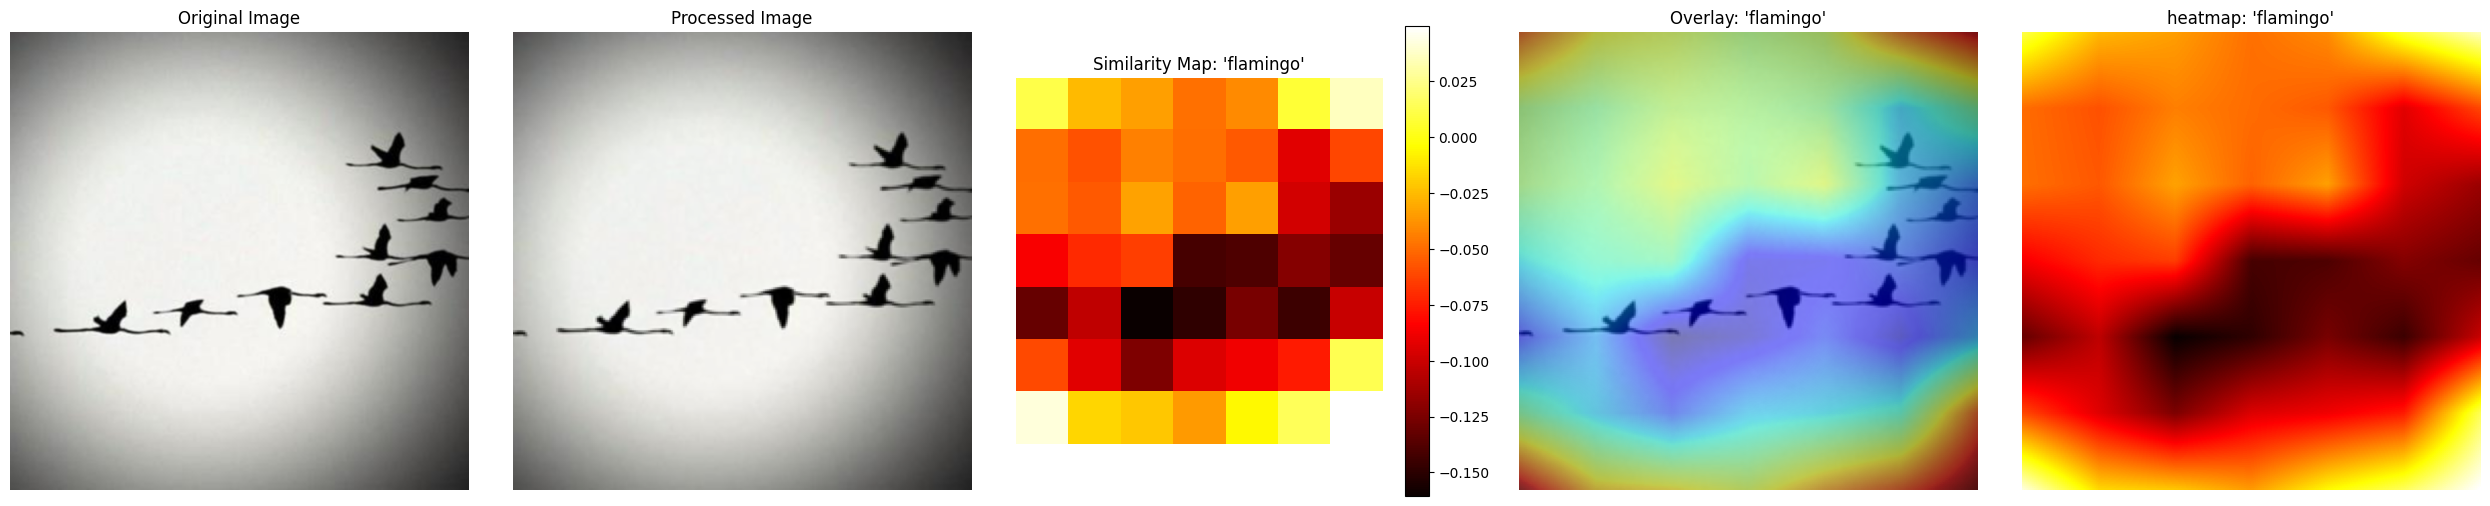

In [10]:
# Đường dẫn ảnh và text
image_path = "/home/hachi/PowerPaint/validation/val/573_b3/ground_truth.png"
text = "flamingo"

# Visualize similarity map
print(f"Analyzing image: {image_path}")
print(f"Text query: '{text}'")

similarity_map = clip_sim.visualize_similarity(image_path, text)